In [67]:
import control as ct
from math import pi

In [68]:
num = [606.1,-2.91e-11]
den = [1,0,9.87e+04]
Gp=ct.tf(num,den)
print(Gp)

<TransferFunction>: sys[166]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  606.1 s - 2.91e-11
  ------------------
    s^2 + 9.87e+04


In [69]:
def pidtune(GH, BW, PM):
    '''Evaluate a PID control used on power eletronics.

    Parameters:
        Open loop plant*sensor transfer function.
        Bandwidth in rad/s.
        Phase margin in degrees.
    '''
    from math import sqrt, tan, radians
    from numpy import angle
    # Evaluate the plant transfer function on the intended bandwidth frequency.
    evaluated_BW = GH(1j * BW)
    evaluation_gain = abs(evaluated_BW)
    evaluation_angle = angle(evaluated_BW)
    # Evaluate the gain and margin phase that the control must apply.
    pi_gain = 1 / evaluation_gain
    pi_phase = radians(PM) - (pi - evaluation_angle)
    # Convert the gain and margin to control gain parameters.
    Kp_Ki = 1 / BW * tan( pi_phase + pi / 2 )
    Ki = pi_gain / sqrt(1 / BW ** 2 + Kp_Ki ** 2)
    Kp = Ki * Kp_Ki
    s =ct.tf('s')
    return Kp + Ki / s

In [119]:
C = pidtune(Gp, 2*pi*1000, 30.0)
print(C)

<TransferFunction>: sys[345]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  5.17 s + 5.627e+04
  ------------------
          s


In [120]:
sys = C * Gp /(1+C*Gp)
print(sys)

<TransferFunction>: sys[350]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     3134 s^5 + 3.41e+07 s^4 + 3.093e+08 s^3 + 3.366e+12 s^2 - 0.1616 s
  ------------------------------------------------------------------------
  s^6 + 3134 s^5 + 3.43e+07 s^4 + 3.093e+08 s^3 + 3.376e+12 s^2 - 0.1616 s


[0.         0.15441761 0.33881789 0.53861466 0.74015446 0.93139981
 1.10243172 1.24576475 1.35647967 1.432189   1.47285843 1.48051264
 1.45885754 1.41285133 1.3482562  1.27119923 1.18776722 1.1036548
 1.02387988 0.95257456 0.89285428 0.8467631  0.81528863 0.79843711
 0.7953565  0.80449447 0.82377755 0.85079832 0.88299857 0.91783828
 0.95294235 0.98621902 1.01594694 1.04082948 1.06001731 1.07310189
 1.08008403 1.08132223 1.07746672 1.0693846  1.05808168 1.04462608
 1.03007771 1.0154272  1.0015465  0.98915268 0.9787854  0.97079755
 0.96535811 0.96246534 0.96196839 0.96359489 0.96698227 0.97171028
 0.97733297 0.98340804 0.98952233 0.99531236 1.00047942 1.00479891
 1.0081242  1.01038542 1.01158386 1.011783   1.01109692 1.00967724
 1.00769954 1.00535    1.0028132  1.00026146 0.99784628 0.99569211
 0.99389242 0.99250814 0.99156815 0.99107168 0.99099201 0.99128137
 0.99187636 0.99270361 0.9936854  0.9947447  0.99580964 0.99681707
 0.99771515 0.99846497 0.99904123 0.99943198 0.99963764 0.99966

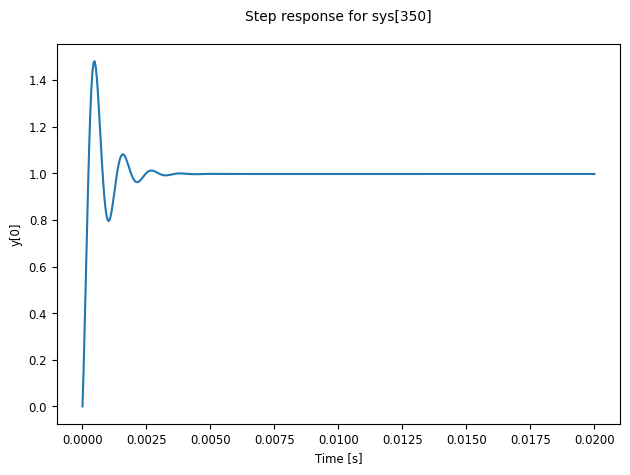

In [121]:
response = ct.step_response(sys, T=0.02)
timepts, output = response.time, response.outputs

print(output)
cplt = response.plot()